Para el modelado, teniendo en cuenta que la idea es entrenar distitnos modelos, compararlos entre ellos y con las base lines (más de una) y con una validación cruzada, se decide trabajar con la libreria `sklearn.pipeline` para facilitar el código y evitar errores.

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyarrow as pa

In [2]:
df_features = pd.read_parquet("..//res//procesed/df_features.parquet")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)   
display(df_features.head(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio
0,2025-10-02 03:12:05.010,ee76d685-a4cc-47d4-b418-6e33d2ae2921,OF2509545,TPP,TN09,TPU,P,PE,3.0,21.0,1.988889


## Baseline

### Baselines: un número
- **B0: ratio = 1** -> es la planificación definida: El ERP acierta.    
- **B1- mediana: ratio** = mediana del train -> si todos los datos tienen una desviación sistematica, cualquier modelo predicirá el sesgo B0: El ERP tiene un sesgo fijo.  
    > mediana suponiendo que trabajemos con MAE, sino será otra la constante.     

- **B1 - media: ratio** = media del train -> si todos los datos tienen una desviación sistematica, cualquier modelo predicirá el sesgo B0: El ERP tiene un sesgo
    > media suponiendo que trabajemos con RMSE, sino será otra constante.

B0 y B1 ignoran por completo las variables de entrada. No saben qué máquina se usa, ni la fase, ni la cantidad.    

> **Importante**: la mediana se calcula solo con el train. Si la calculas con todo el dataset, el baseline "conoce" el test. Sería leakage, igual que en un modelo.

**Constante B1**: A favor de la **mediana** y no la **media**: el ratio es asimétrico (cola larga a la derecha, por eso te planteas log(ratio)). Unas pocas fases con ratio 6 u 8 inflan la media, mientras que la mediana representa mejor a la "fase típica".

### Baselines: Una tabla de consulta (referencia intermedia)
Constante general o por maquian y linea de producto
- **B2 - media o mediana ratio por grupo = cosntante del train**
    > Deben elegirse grupos con suficientes fases en train
Ahora **B2** ya utilizará información de las variables. 

```text
B0 (ERP) ──► B1 (corrijo sesgo global) ──► B2 (tabla por grupo) ──► Modelo ML        
  │                 │                              │                    │                            
  └ ¿ERP sesgado? ──┘                              │                    │       
                    └ ¿las variables aportan algo? ┘                    │          
                                                   └ ¿compensa el ML? ──┘        
```

Si los modelos no superan B2: hay señal, pero una tabla simple la captura casi toda. Eso también es un resultado válido y defendible.

## Split de Datos
Teniendo en cuenta la naturaleza de estos datos es necesario plantear un split temporal. Para ello el campo `fecha_fase` permite identificar la fecha en que se empezó la fase.      

Una Orden de Fabricación puede tener distintas Fases, para este split es importante que las Fases de una misma Orden no se separen. Es decir, las Fases de una misma Orden no pueden aparecer en distitnas particiones.     

Jacky recomienda: El ajuste de hiperparámetros se hace solo dentro de train, con TimeSeriesSplit. El test se toca una única vez, al final     

Análisis de Generalización: dentro del test se marcan las fases de órdenes o combinaciones máquina-fase no vistas en train y se reporta su error por separado.

Es planteable tener un split estratificado como análisis secundario. 

Pasos para dar el split:
- 1. Explorar la cobertura temporal   
- 2. Decidir los cortes y asignar cada orden a un bloque
- 3. Asignar cada orden a un bloque temporal
- 4. Verificar y guardar dataset en el repositorio (dataset_split.parquet)

### 1. Explorar la cobertura temporal

In [3]:
print(df_features.shape)
print(df_features["fecha_fase"].describe())

(14223, 11)
count                            14223
mean     2025-12-20 00:31:47.864819712
min         2025-06-02 14:01:02.623000
25%      2025-09-10 08:28:52.863500032
50%         2025-12-05 06:09:50.400000
75%      2026-03-30 12:42:31.763500032
max         2026-07-31 14:31:26.853000
Name: fecha_fase, dtype: object


Acumulación de Ordenes de Fabricación por trimestre:

In [4]:
resumen_trim = (
    df_features.assign(trimestre=df_features["fecha_fase"].dt.to_period("Q"))
      .groupby("trimestre")
      .agg(fases=("IDMOTask", "size"),
           ordenes=("smOrdenId", "nunique"))
)
resumen_trim["fases_acum_%"] = (resumen_trim["fases"].cumsum()  
                                / len(df_features) * 100).round(1)
#resumen_trim["fases_acum_%"] Es el porcentaje acumulado de fases a medida que avanzan los trimestres.
print(resumen_trim)

           fases  ordenes  fases_acum_%
trimestre                              
2025Q2       650      335           4.6
2025Q3      3745     1751          30.9
2025Q4      3400     1627          54.8
2026Q1      2947     1426          75.5
2026Q2      2617     1333          93.9
2026Q3       864      442         100.0


> El split se hará por mese no por trimestres, el primer y ultimo trimestre del intervalo estan incompletos.

Duración de las Ordenes de Fabricación:

In [5]:
OF_dias = (
    df_features.groupby("smOrdenId")["fecha_fase"] # agrupar las fases por OF
      .agg(primera="min", ultima="max", n_fases="size") # de cada grupo obtener las fechas
)
OF_dias["dias"] = (OF_dias["ultima"] - OF_dias["primera"]).dt.days # mostrando el tiempo en dias, menos de 24h da 0.

display(OF_dias.sample(1))
print(OF_dias["dias"].describe(percentiles=[.5, .75, .9, .95, .99]))

,primera,ultima,n_fases,dias
smOrdenId,,,,
OF2512479,2025-12-19 11:51:04.817,2026-01-09 19:20:20.250,3,21


count    6386.000000
mean        6.059505
std         8.298139
min         0.000000
50%         2.000000
75%        10.000000
90%        18.000000
95%        23.000000
99%        35.000000
max        61.000000
Name: dias, dtype: float64


>Las ordenes en su mayoria son cortas, concretamente la mediana muestra que la mitad de las órdenes duran menos de este valor.  

>A partir del 90% se acumulan 18 dias, y la orden más larga registra 61 dias.    

>Que una orden tarde muchos dias no significa que sus fases acumulen mucho tiempo, algunas ordenes, por su naturaleza, pasan mucho tiempo en el taller.

#### Revisión de las fases por mes

In [6]:
resumen_mes = (
    df_features.assign(mes=df_features["fecha_fase"].dt.to_period("M"))
      .groupby("mes")
      .agg(fases=("IDMOTask", "size"),
           ordenes=("smOrdenId", "nunique"))
)
resumen_mes["fases_acum_%"] = (resumen_mes["fases"].cumsum() / len(df_features) * 100).round(1)
print(resumen_mes)

         fases  ordenes  fases_acum_%
mes                                  
2025-06    650      335           4.6
2025-07   1573      794          15.6
2025-08    947      578          22.3
2025-09   1225      670          30.9
2025-10   1312      718          40.1
2025-11   1163      637          48.3
2025-12    925      516          54.8
2026-01    999      563          61.8
2026-02   1003      517          68.9
2026-03    945      482          75.5
2026-04   1008      535          82.6
2026-05    689      432          87.5
2026-06    920      485          93.9
2026-07    864      442         100.0


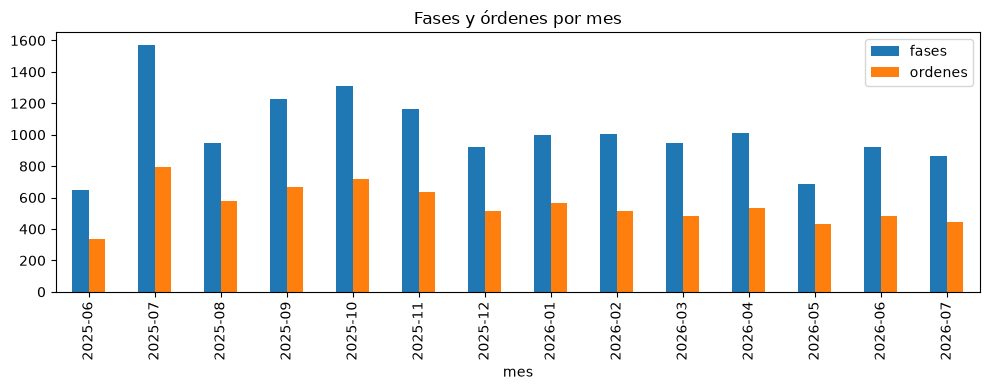

In [7]:
resumen_mes[["fases", "ordenes"]].plot(kind="bar", 
                                       figsize=(10, 4), 
                                       title="Fases y órdenes por mes")

plt.tight_layout()
plt.show()

> Es clave escoger validación cruzada, para evitar caer en meses atipicos para validación.

#### 2. Fijar los cortes del split
En total se abarcan 14 meses. El reparto de los meses a de hacerse con números enteros, no puden ser decimales. 
- Train: El 60% de 14 es 8,4 -> 9
- Validación: El 15% de 14 es 2,1 --> 2
- Test: El 25% de 14 es 3,5 -> 3  

Esto da una estimacoón orientativa de como podria hacerse el split.



### 3. Asignar cada orden a un bloque temporal


Cada orden debe pertenecer al mes en que se hizo su primera imputación.

Corte Test:

In [8]:
CORTE_TEST = pd.Timestamp("2026-05-01")

# 1. Fecha de la primera fase de cada orden
primera_fase = df_features.groupby("smOrdenId")["fecha_fase"].min()

# 2. Añadir columna con la fecha de inicio de la orden
df_features["inicio_orden"] = df_features["smOrdenId"].map(primera_fase)

# 3. Añadir el mes de inicio de la orden (servirá para los folds de validación)
df_features["mes_orden"] = df_features["inicio_orden"].dt.to_period("M")

# 4. Bloque según el inicio de la orden
df_features["split"] = np.where(df_features["inicio_orden"] < CORTE_TEST, "desarrollo", "test")

df_split = df_features

print(df_split["split"].value_counts(normalize=True).round(3))

split
desarrollo    0.832
test          0.168
Name: proportion, dtype: float64


### 4.Verificar el Split

Reviso aquellas OF que estan en medio del corte, estas son las que tienen fases antes del corte y fases después.

In [9]:
invaden = df_split[(df_split["split"] == "desarrollo") &
                      (df_split["fecha_fase"] >= CORTE_TEST)]
print(f"Fases de desarrollo posteriores al corte: {len(invaden)} "
      f"({len(invaden) / len(df_split):.1%})")

Fases de desarrollo posteriores al corte: 77 (0.5%)


Decido conservar esas fases, justificación para la memoria:      
La partición temporal se realiza a nivel de orden de fabricación, según la fecha de inicio de cada OF. Las órdenes iniciadas antes del 1 de mayo de 2026 se asignan íntegramente al conjunto de desarrollo, aunque alguna de sus fases se ejecute con posterioridad (77 fases, 0,5 %)

Reviso el reparto de los artículos entre los splits:

In [10]:
for col in ["Línea Producto", "Família Producto", "Familia Maquinas"]:
    print(pd.crosstab(df_split[col], df_split["split"], normalize="columns").round(3), "\n")

split           desarrollo   test
Línea Producto                   
B                    0.260  0.261
CBN                  0.002  0.003
CF                   0.011  0.018
CO                   0.025  0.027
E                    0.062  0.072
IC                   0.010  0.013
IT                   0.005  0.013
K                    0.000  0.006
M                    0.004  0.005
MAT                  0.000  0.002
P                    0.600  0.559
PBA                  0.011  0.007
PL                   0.006  0.007
PRJ                  0.000  0.000
REP                  0.000  0.000
SUP                  0.000  0.001
T                    0.004  0.006 

split             desarrollo   test
Família Producto                   
BAL                    0.038  0.038
BR                     0.168  0.170
BX                     0.054  0.054
CBN                    0.002  0.003
CFF                    0.011  0.018
COD                    0.016  0.017
COP                    0.003  0.002
COR                    0.006

In [11]:
for col in ["CodigoMaquina", "Familia Maquinas", "TipoFase", "Línea Producto", "Família Producto"]:
    nuevas = set(df_split.loc[df_features["split"] == "test", col]) - \
             set(df_split.loc[df_features["split"] == "desarrollo", col])
    print(f"{col}: {len(nuevas)} categorías solo en test → {nuevas}")

CodigoMaquina: 1 categorías solo en test → {'CM19'}
Familia Maquinas: 0 categorías solo en test → set()
TipoFase: 0 categorías solo en test → set()
Línea Producto: 0 categorías solo en test → set()
Família Producto: 1 categorías solo en test → {'KCX'}


La máquina CM19 no esta en la partición de entrenamiento, esto se debe a que la maquina fue incorporada a finales del mayo 2026. 

Esto es destacable: → ¿Cómo predice el modelo en una máquina que nunca ha visto, apoyándose solo en su familia?

Dejare una marca en esa maquina, esta marca no sera una variable del modelo (nunca entra en el entrenamiento ni en la predicción), sino una etiqueta de análisis, se usa después de predecir, para separar el error en grupos.

##### Split Desarroyo y Test

Primero dejo marcadas las fases que solo estan en test

In [12]:
maquinas_desarrollo = set(df_split.loc[df_split["split"] == "desarrollo", "CodigoMaquina"])
df_split["maquina_no_vista"] = ~df_split["CodigoMaquina"].isin(maquinas_desarrollo)

print('='*60)
print("Fases en máquinas no vistas en entrenamiento:")
print(df_split.groupby("split")["maquina_no_vista"].sum())
print('='*60)
print("Máquinas no vistas en entrenamiento:")
print(df_split.loc[df_split["maquina_no_vista"], "CodigoMaquina"].unique())
print('='*60)
peso = df_split["maquina_no_vista"].sum() / len(df_split) 
print(f"Peso de esa imputaciones en el conjunto de test: {peso:.1%}")
print('='*60)

Fases en máquinas no vistas en entrenamiento:
split
desarrollo     0
test          36
Name: maquina_no_vista, dtype: int64
Máquinas no vistas en entrenamiento:
['CM19']
Peso de esa imputaciones en el conjunto de test: 0.3%


Los resultados cuadran con lo visto, estas fases no vistas en entrenamiento suponen un 0.3% del conjunto de test. 

In [13]:
df_split["mes_orden"] = df_split["mes_orden"].astype(str)   # '2025-06', ... (parquet no guarda bien el tipo Period)

df_split.to_parquet("datos/df_split.parquet", index=False)

# Comprobación: se relee y coincide
check = pd.read_parquet("datos/df_split.parquet")
print(check.shape)
print(check["split"].value_counts())

(14223, 15)
split
desarrollo    11827
test           2396
Name: count, dtype: int64


Apenas modificamos el dataset, ya que cada modelo precisara de su propio feature engeniering. 

##### Split Entrenamiento y Validación

Se ha determinado ejecutar validación cruzada. Al trabajar con datos temporales no puede aplicarse un reparto como el visto en clase, ya que le fold que valide no puede estar temporalmente por delante de datos de entrenamiento. Los folds siempre deberan de ser para datos a futuro del entrenamient. 

In [14]:
# inspecionar cuantos kfold elegir:

desarrollo = df_split[df_split["split"] == "desarrollo"]
meses = sorted(desarrollo["mes_orden"].unique())          # los 11 meses de desarrollo, en orden
fases_mes = desarrollo["mes_orden"].value_counts()

filas = []
for k in range(2, 6):
    meses_val = meses[-k:]                                # los k últimos meses validan
    train_fold1 = desarrollo[desarrollo["mes_orden"] < meses_val[0]]
    filas.append({
        "k": k,
        "meses_validacion": ", ".join(meses_val),
        "meses_train_fold1": len(meses) - k,
        "fases_train_fold1": len(train_fold1),
        "%_datos_fold1": round(len(train_fold1) / len(df_split) * 100, 1),
        "fases_val_min": fases_mes[meses_val].min(),      # el mes de validación más flojo
    })

print(pd.DataFrame(filas).to_string(index=False))

 k                            meses_validacion  meses_train_fold1  fases_train_fold1  %_datos_fold1  fases_val_min
 2                            2026-03, 2026-04                  9               9859           69.3            971
 3                   2026-02, 2026-03, 2026-04                  8               8940           62.9            919
 4          2026-01, 2026-02, 2026-03, 2026-04                  7               7962           56.0            919
 5 2025-12, 2026-01, 2026-02, 2026-03, 2026-04                  6               7090           49.8            872


Mantengo la decision de abarcar 3 meses para validación, entonces defino k=3

In [15]:
# Guardo como csv los folds para no tener que definirlos cada vez que los use

MESES_VALIDACION = ["2026-02", "2026-03", "2026-04"]

folds = pd.DataFrame({
    "fold": range(1, len(MESES_VALIDACION) + 1),
    "mes_validacion": MESES_VALIDACION,
})
print(folds)

folds.to_csv("datos/folds.csv", index=False)

   fold mes_validacion
0     1        2026-02
1     2        2026-03
2     3        2026-04
